# Imports

In [1]:
%reload_ext autoreload
%autoreload 2
%matplotlib inline
import seaborn as sns
from typing import Optional
import pandas as pd
import numpy as np
from scipy import sparse
from anndata import AnnData
import scanpy as sc
import torch
from ciim.src.utils.util import bulkify_func
torch.set_float32_matmul_precision('medium')
from ciim.src.clock.NN.helper import test_datasets, train_datasets, format_data, save_path_train, save_path_test, wrapper_setup_data, cell_type_train, data_type, batch_key, plot_history, wrapper_umap

import torch
from ciim.src.common import datasets_all
import cpa


def plot_age_prediction(adata):
    from sklearn.metrics import r2_score
    from scipy.stats import spearmanr
    import seaborn as sns
    import matplotlib.pyplot as plt
    fig, ax = plt.subplots(figsize=(6, 6))

    datasets = adata.obs['dataset'].unique()
    for dataset in datasets:
        subset = adata.obs[adata.obs['dataset'] == dataset]
        age = subset['age']
        pred = subset['predicted_age']

        r2 = r2_score(age, pred)
        rho, _ = spearmanr(age, pred)

        label = f"{dataset} (ρ={rho:.2f}, R²={r2:.2f})"
        sns.scatterplot(x=age, y=pred, s=10, ax=ax, label=label)

    # Plot diagonal reference line
    min_age = adata.obs['age'].min()
    max_age = adata.obs['age'].max()
    ax.plot([min_age, max_age], [min_age, max_age], 'r--', label="Identity")

    ax.set_xlabel("True Age")
    ax.set_ylabel("Predicted Age")
    ax.legend()
    ax.set_title("Age Prediction per Dataset")
    plt.tight_layout()
    plt.show()
def normalize(adata):
    adata.X = adata.X.todense().A if sparse.issparse(adata.X) else adata.X
    sc.pp.normalize_total(adata, target_sum=1e4)
    sc.pp.log1p(adata)
    return adata

# ---- simple aging clock
import numpy as np
from sklearn.linear_model import Ridge
from sklearn.model_selection import KFold
from sklearn.metrics import r2_score
from sklearn.preprocessing import StandardScaler
from scipy.stats import spearmanr
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from ciim.src.clock.helper import align_feature_space

class age_predictor:
    def __init__(self):
        self.reg = Ridge(alpha=1.0)
    def format_data(self, adata: AnnData):
        X = adata.X
        y = adata.obs["age"].values.astype(np.float32)
        group = adata.obs["donor_age"].values
        batch = adata.obs["dataset"].values
        return X, y, group, batch
    def train(self, adata):
        X, y, _, _ = self.format_data(adata)
        self.features = adata.var_names
        self.reg.fit(X, y)
    def predict(self, adata):
        adata = align_feature_space(adata, self.features)
        X, y, group, batch = self.format_data(adata)
        y_pred = self.reg.predict(X)
        self.evaluate(y_pred, y, group, batch)

    def train_cv(self, adata):
        X, y, group, batch = self.format_data(adata)
        cv = KFold(n_splits=5, shuffle=True, random_state=0)

        y_pred_store = []
        y_true_store = []
        group_store = []
        batch_store = []

        for train_idx, test_idx in cv.split(X):
            X_train, X_test = X[train_idx], X[test_idx]
            y_train, y_test = y[train_idx], y[test_idx]
            group_test = group[test_idx]
            batch_test = batch[test_idx]

            # Standardize
            # X_train = scaler.fit_transform(X_train)
            # X_test = scaler.transform(X_test)

            self.reg.fit(X_train, y_train)
            y_pred = self.reg.predict(X_test)

            y_pred_store.append(y_pred)
            y_true_store.append(y_test)
            group_store.append(group_test)
            batch_store.append(batch_test)

        # Concatenate results
        y_pred = np.concatenate(y_pred_store)
        y_test = np.concatenate(y_true_store)
        group_all = np.concatenate(group_store)
        batch_all = np.concatenate(batch_store)
        self.evaluate(y_pred, y_test, group_all, batch_all)
    def evaluate(self, y_pred, y_test, group_all, batch_all):
        # Aggregate by group and batch
        df = pd.DataFrame({
            "y_pred": y_pred,
            "y_true": y_test,
            "group": group_all,
            "batch": batch_all
        })
        df['group'] = df['group'].astype(str)
        df['batch'] = df['batch'].astype(str)
        df_grouped = df.groupby(["group", "batch"], as_index=False).median()

        # Compute metrics
        rho, _ = spearmanr(df_grouped["y_true"], df_grouped["y_pred"])
        r2 = r2_score(df_grouped["y_true"], df_grouped["y_pred"])

        print(f"Spearman correlation (per donor): {rho:.2f}, R² (per donor): {r2:.2f}")
    
        # Plot prediction
        plt.figure(figsize=(4, 4))
        sns.scatterplot(data=df_grouped, x="y_true", y="y_pred", hue="batch", alpha=0.7)
        min_val = min(df_grouped["y_true"].min(), df_grouped["y_pred"].min())
        max_val = max(df_grouped["y_true"].max(), df_grouped["y_pred"].max())
        plt.plot([min_val, max_val], [min_val, max_val], "r--")
        plt.xlabel("True median age (per donor)")
        plt.ylabel("Predicted median age (per donor)")
        # plt.title("Ridge regression on latent space")
        plt.legend(loc=(1, .8), frameon=False)
        # plt.tight_layout()

[rank: 0] Global seed set to 0


# EXA

In [2]:
adata_train = format_data(train_datasets, cell_type_train, data_type)

In [3]:
adata_train

AnnData object with n_obs × n_vars = 1140 × 10201
    obs: 'sum_by', 'orig.ident', 'Major_CT', 'age', 'donor_id', 'sex', 'batch_info', 'dataset', 'donor_age', 'cell_type', 'cell_count', 'disease'

In [8]:
adata_test = format_data(test_datasets, cell_type_train, data_type)
adata_test = align_feature_space(adata_test, adata_train.var_names)

In [9]:
if data_type=='sc':
    adata_train_bulk = bulkify_func(adata_train, covariates=['cell_type', 'donor_id', 'age'])
    adata_test_bulk = bulkify_func(adata_test, covariates=['cell_type', 'donor_id', 'age'])

    adata_train_bulk = normalize(adata_train_bulk)
    adata_test_bulk = normalize(adata_test_bulk)
else:
    adata_train_bulk = adata_train
    adata_test_bulk = adata_test

Spearman correlation (per donor): 0.83, R² (per donor): 0.71
Spearman correlation (per donor): 0.80, R² (per donor): 0.33


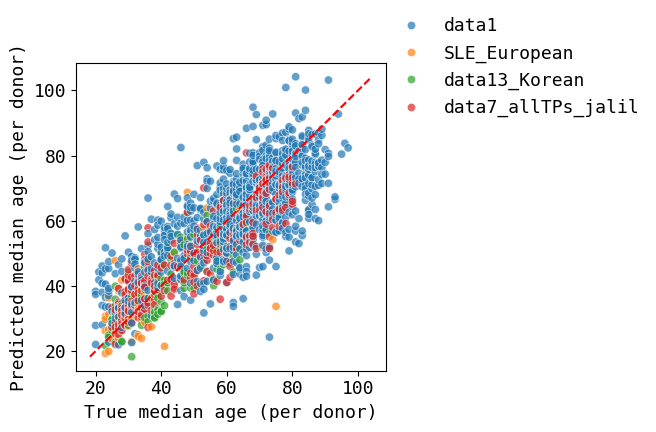

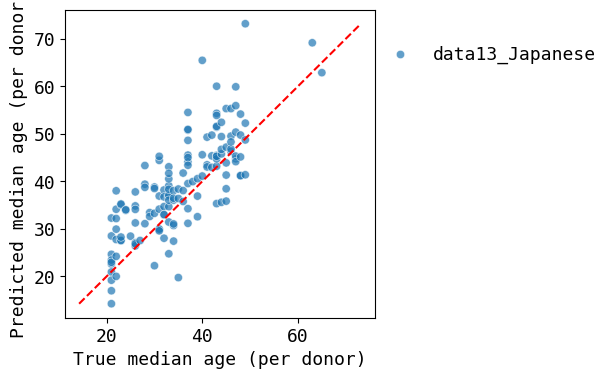

In [10]:
for cell_type in ['CD8T']:
    adata_train_bulk_t = adata_train_bulk[adata_train_bulk.obs['cell_type'] == cell_type].copy()
    adata_test_bulk_t = adata_test_bulk[adata_test_bulk.obs['cell_type'] == cell_type].copy()
    obj = age_predictor()
    obj.train_cv(adata_train_bulk_t)
    obj.train(adata_train_bulk_t)
    obj.predict(adata_test_bulk_t)

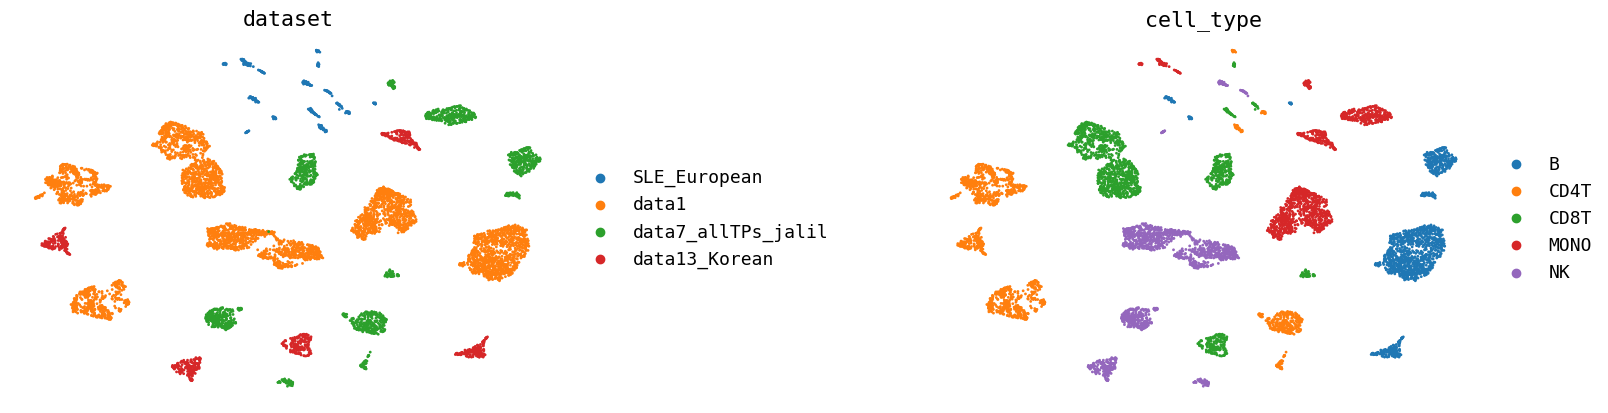

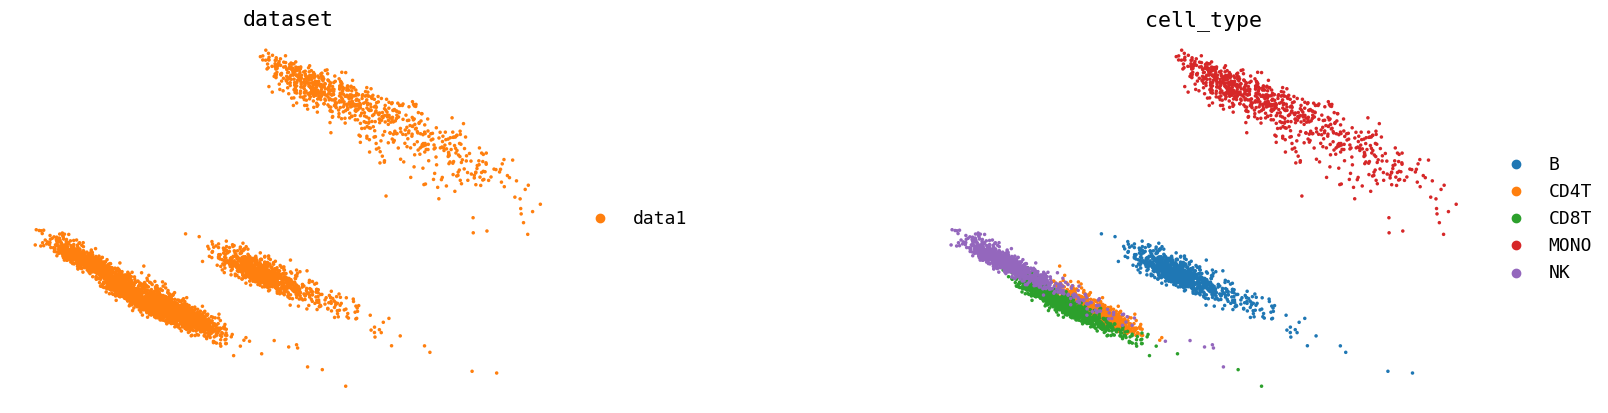

In [17]:
# - original data embedding
if True:
    adata_raw = adata_train.copy()
    if data_type=='sc':
        sc.pp.normalize_total(adata_raw)
        sc.pp.log1p(adata_raw)
    # sc.pp.highly_variable_genes(adata_raw, n_top_genes=2000, subset=True)
    sc.pp.pca(adata_raw)
    wrapper_umap(adata_raw)

    sc.pl.pca(adata_raw[adata_raw.obs['dataset'] == 'data1'],
            color=['dataset', 'cell_type'],
            frameon=False,
            wspace=0.5)

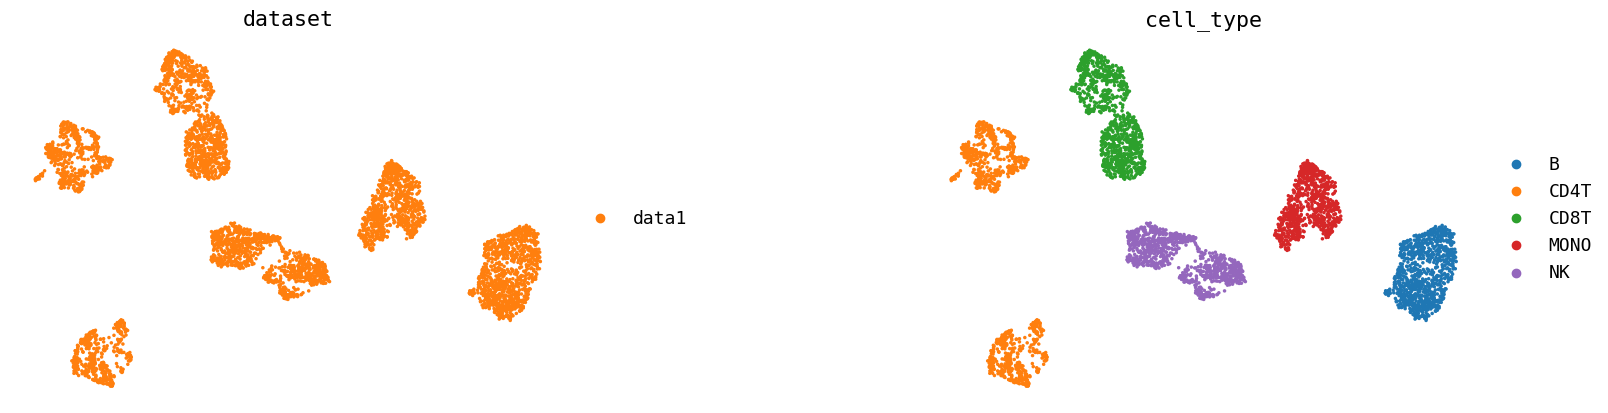

In [ ]:
sc.pl.umap(adata_raw[adata_raw.obs['dataset'] == 'data1'],
            color=['dataset', 'cell_type'],
            frameon=False,
            wspace=0.5)

In [19]:
aaa

NameError: name 'aaa' is not defined

# Train

In [33]:
# run ../scripts/run_train_nn.sh

# Evaluate on train data

-TODO: 1. train with the original version. 2. reduce the epock, 3. make it 'nb'. 4. train with larger datasets 

INFO     File /home/jnourisa/projs/ongoing/ciim//output//NN/bulk_train/model.pt already downloaded                 


[rank: 0] Global seed set to 6977


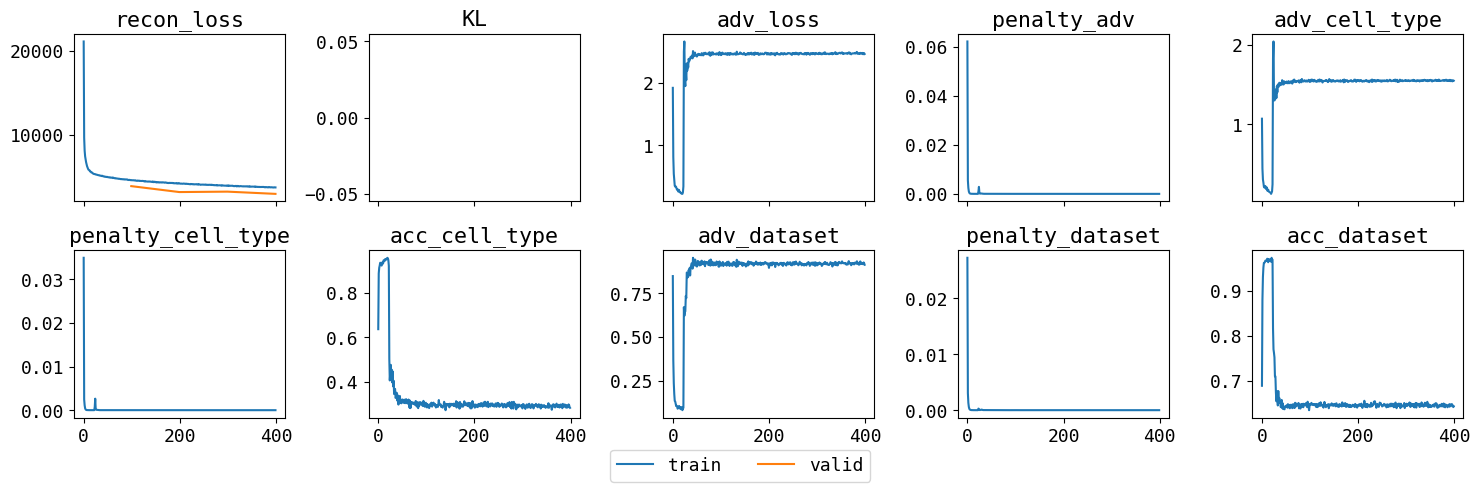

In [4]:
import cpa
from ciim.src.common import save_dir
# save_path_train=f'{save_dir}/NN/try1' # trained with cleaned cpa, zinb, ['SLE_European', 'data12', 'data13_Korean']

model = cpa.CPA.load(dir_path=save_path_train)
plot_history(model)

In [3]:
# print(model.adata_manager._registry)
# print(model.covars_encoder)

NameError: name 'model' is not defined

In [5]:
# adata = model.adata.copy()
adata_train = format_data(train_datasets, cell_type_train, data_type)
adata = adata_train.copy()
wrapper_setup_data(adata, data_type=data_type, batch_key=batch_key, cell_type=cell_type_train)
latent_dict = model.get_latent_representation(adata=adata)
adata_corrected = latent_dict['latent_corrected']

Setting up data without cell type filtering.
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             


100%|██████████| 234/234 [00:01<00:00, 201.68it/s]


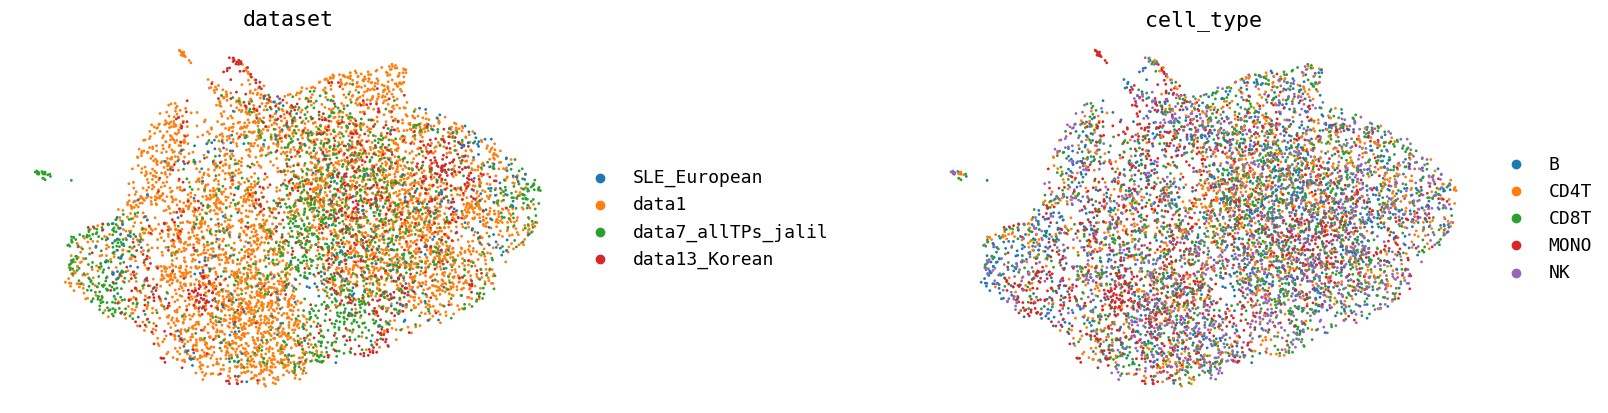

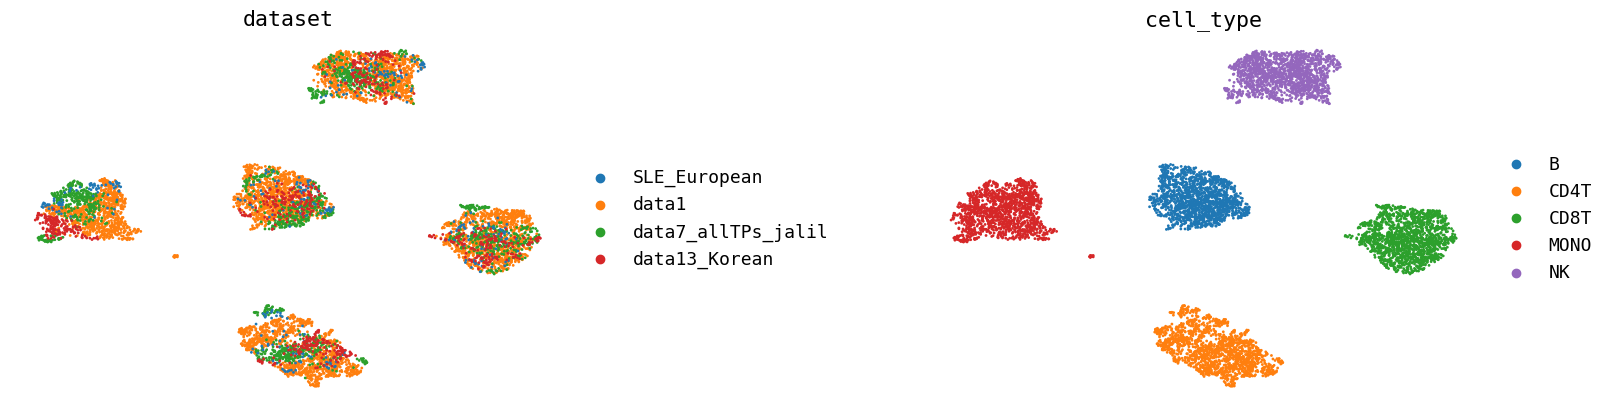

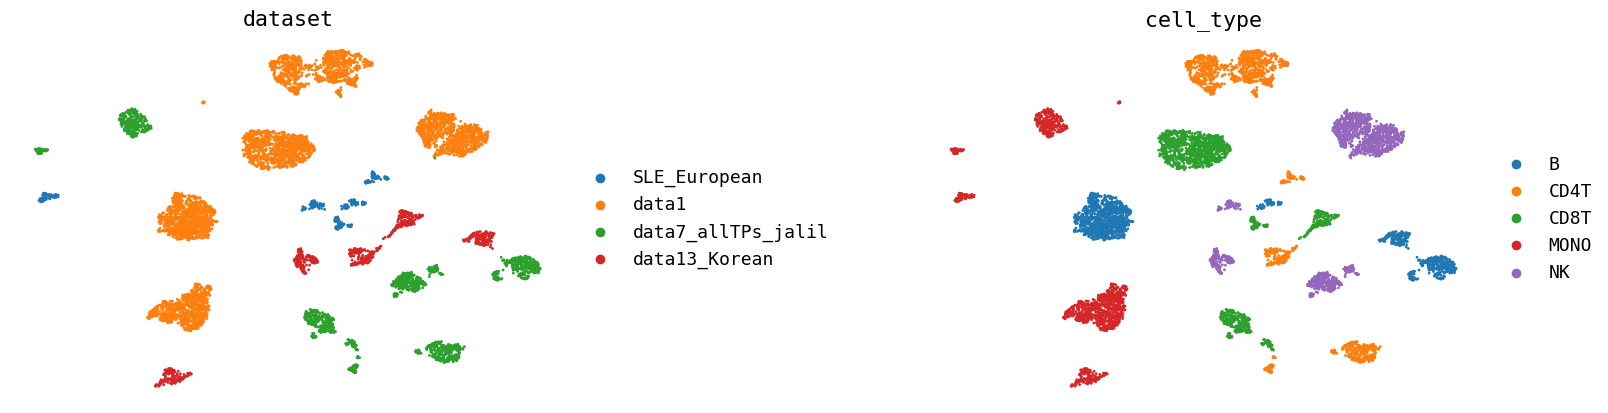

In [6]:
if True:
    wrapper_umap(latent_dict['latent_basal'])
    wrapper_umap(latent_dict['latent_corrected'])
    wrapper_umap(latent_dict['latent_after'])

Spearman correlation (per donor): 0.75, R² (per donor): 0.57


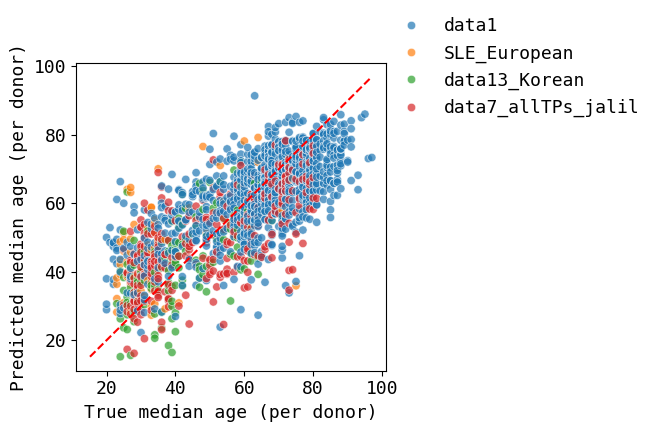

In [7]:
if data_type == 'sc':
    adata_corrected_bulk = bulkify_func(adata_corrected, covariates=['cell_type', 'donor_id', 'age'])
else:
    adata_corrected_bulk = adata_corrected
for cell_type in ['CD8T']:
    adata_corrected_bulk_t = adata_corrected_bulk[adata_corrected_bulk.obs['cell_type'] == cell_type].copy()

    obj = age_predictor()
    obj.train_cv(adata_corrected_bulk_t)

In [7]:
# obj = age_predictor()
# obj.train(adata_corrected_bulk_t)
# obj.predict(adata_test_bulk_t)

In [8]:
aaa

NameError: name 'aaa' is not defined

# Train on test data

In [8]:
from ciim.src.clock.NN.helper import get_params
# model_params, trainer_params = get_params(data_type)

    
print("Testing mode activated.")
print('Loading model ... ')
model = cpa.CPA.load(dir_path=save_path_train)
assert len(test_datasets)==1, "Testing mode requires exactly one test dataset."
print('Loading training data ... ')
adata_train = model.adata
print('Loading test data ... ')
adata_test = format_data(test_datasets, cell_type, data_type)
from ciim.src.clock.helper import align_feature_space
adata_test = align_feature_space(adata_test, adata_train.var_names)

model.setup_anndata_test(adata_test, is_count_data=True if data_type == 'sc' else False)

print('Extending embedding for test dataset ... ')
model.extend_embedding(new_dataset=test_datasets[0], covariate=batch_key)
print(model.covars_encoder)


Testing mode activated.
Loading model ... 
INFO     File /home/jnourisa/projs/ongoing/ciim//output//NN/bulk_train/model.pt already downloaded                 


[rank: 0] Global seed set to 6977


Loading training data ... 
Loading test data ... 
Extending embedding for test dataset ... 
covars_embeddings.dataset.weight: trainable
{'cell_type': {'B': 0, 'CD4T': 1, 'CD8T': 2, 'MONO': 3, 'NK': 4}, 'dataset': {'SLE_European': 0, 'data1': 1, 'data13_Korean': 2, 'data7_allTPs_jalil': 3, 'data13_Japanese': 4}}


In [9]:
model.register

AttributeError: 'CPA' object has no attribute 'register'

In [ ]:

model._register_manager_for_instance(
                model.adata_manager.transfer_fields(adata_test, extend_categories=True)
        )
model.adata = adata_test

In [211]:
init_weight_layer0 = model.module.covars_embeddings['dataset'].weight[0][0:2]
init_weight_layer_new = model.module.covars_embeddings['dataset'].weight[-1][0:2]
print(f"Initial weight for first dataset: \n {init_weight_layer0}")
print(f"Initial weight for new dataset: \n {init_weight_layer_new}")

Initial weight for first dataset: 
 tensor([-0.9646, -0.5713], grad_fn=<SliceBackward0>)
Initial weight for new dataset: 
 tensor([-2.0618, -1.2709], grad_fn=<SliceBackward0>)


In [212]:
trainer_params = {
        "n_epochs_kl_warmup": None,
        "n_epochs_pretrain_ae": 1,
        "n_epochs_adv_warmup": 1,
        "n_epochs_mixup_warmup": 0,
        "mixup_alpha": 0.0,
        "use_batch_norm_adv": True,
        "use_layer_norm_adv": False,
        "dropout_rate_adv": 0.3,
        "reg_adv": 20,
        "pen_adv": 5,
        "lr": 0.0003,
        "wd": 4e-07,
        "adv_lr": 0.0003,
        "adv_wd": 4e-07,
        "adv_loss": "cce",
        "do_clip_grad": True,
        "gradient_clip_value": 1.0,
        "step_size_lr": 10,
    }
model.train(max_epochs=200,
        initial_training = False,
        use_gpu=True,
        batch_size=10,
        plan_kwargs=trainer_params,
        early_stopping_patience=5,
        check_val_every_n_epoch=100,
        save_path=save_path_test,
    )

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Epoch 100/200:  50%|████▉     | 99/200 [00:10<00:06, 15.01it/s, v_num=1, recon=6.94e+4, adv_loss=nan, acc_cell_type=nan, acc_dataset=nan]


Epoch 00099: recon reached. Module best state updated.


Epoch 200/200: 100%|█████████▉| 199/200 [00:17<00:00, 15.32it/s, v_num=1, recon=6.87e+4, adv_loss=nan, acc_cell_type=nan, acc_dataset=nan, val_recon=6.81e+4, val_KL=nan]


Epoch 00199: recon reached. Module best state updated.


Epoch 200/200: 100%|██████████| 200/200 [00:17<00:00, 14.97it/s, v_num=1, recon=6.87e+4, adv_loss=nan, acc_cell_type=nan, acc_dataset=nan, val_recon=6.75e+4, val_KL=nan]

`Trainer.fit` stopped: `max_epochs=200` reached.


Epoch 200/200: 100%|██████████| 200/200 [00:17<00:00, 11.41it/s, v_num=1, recon=6.87e+4, adv_loss=nan, acc_cell_type=nan, acc_dataset=nan, val_recon=6.75e+4, val_KL=nan]


In [213]:
init_weight_layer0 = model.module.covars_embeddings['dataset'].weight[0][0:2]
init_weight_layer_new = model.module.covars_embeddings['dataset'].weight[-1][0:2]
print(f"Initial weight for first dataset: \n {init_weight_layer0}")
print(f"Initial weight for new dataset: \n {init_weight_layer_new}")

Initial weight for first dataset: 
 tensor([-0.9643, -0.5710], device='cuda:0', grad_fn=<SliceBackward0>)
Initial weight for new dataset: 
 tensor([-1.3887, -0.5390], device='cuda:0', grad_fn=<SliceBackward0>)


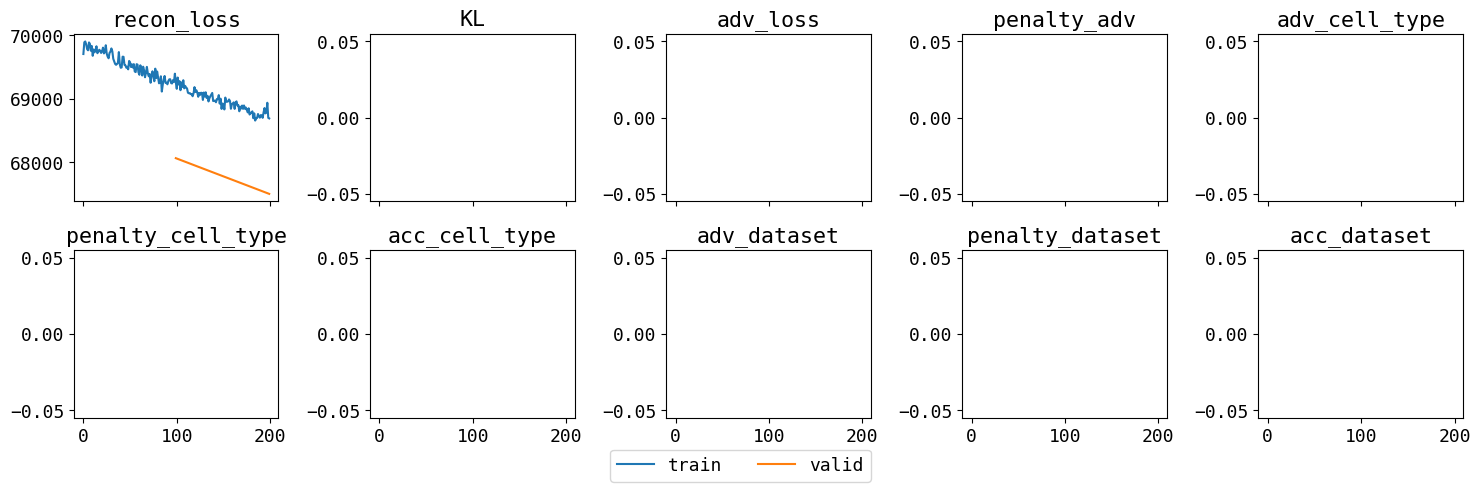

In [214]:
plot_history(model)

In [215]:
aaa

NameError: name 'aaa' is not defined

# Evaluate on test data

In [2]:
save_path_test

'/home/jnourisa/projs/ongoing/ciim//output//NN/bulk_test'

In [ ]:
# model._register_manager_for_instance(
#                 model.adata_manager.transfer_fields(adata_test, extend_categories=True)
#         )
# model._validate_anndata(adata_test)

AnnData object with n_obs × n_vars = 147 × 9674
    obs: 'sum_by', 'Major_CT', 'dataset', 'cell_type', 'batch_info', 'race', 'age', 'donor_id', 'orig.ident', 'donor_age', 'sex', 'cell_count', 'disease', 'CPA_cat', '_scvi_cell_type', '_scvi_dataset', '_scvi_CPA_cat'
    var: 'gene_symbols'
    uns: '_scvi_uuid', '_scvi_manager_uuid'

In [2]:
model_test = cpa.CPA.load(dir_path=save_path_test)

INFO     File /home/jnourisa/projs/ongoing/ciim//output//NN/bulk_test/model.pt already downloaded                  
{'scvi_version': '0.20.3', 'model_name': 'CPA', 'setup_args': {'batch_key': 'dataset', 'layer': None, 'smiles_key': None, 'is_count_data': False, 'categorical_covariate_keys': ['cell_type', 'dataset'], 'deg_uns_key': None, 'deg_uns_cat_key': None, 'max_comb_len': 1, 'category_key': 'CPA_cat', 'keys': ['dataset', 'cell_type']}, 'field_registries': defaultdict(<class 'dict'>, {'X': {'data_registry': {'attr_name': 'X', 'attr_key': None}, 'state_registry': {'n_obs': 147, 'n_vars': 9674, 'column_names': array(['LINC01409', 'NOC2L', 'HES4', ..., 'TCEA2', 'RGS19', 'PCMTD2'],
      dtype=object)}, 'summary_stats': {'n_vars': 9674, 'n_cells': 147}}, 'cell_type': {'data_registry': {'attr_name': 'obs', 'attr_key': '_scvi_cell_type'}, 'state_registry': {'categorical_mapping': array(['B', 'CD4T', 'CD8T', 'MONO', 'NK'], dtype=object), 'original_key': 'cell_type'}, 'summary_stats': {'n_

NameError: name 'aaa' is not defined

In [21]:
model_test.covars_encoder

{'cell_type': {'B': 0, 'CD4T': 1, 'CD8T': 2, 'MONO': 3, 'NK': 4},
 'dataset': {'SLE_European': 0,
  'data1': 1,
  'data13_Korean': 2,
  'data7_allTPs_jalil': 3,
  'data13_Japanese': 4}}

In [22]:
import anndata as ad
adata_all = ad.concat([adata_train, adata_test], axis=0)
wrapper_setup_data(adata_all, data_type=data_type, batch_key=batch_key, cell_type=cell_type)
latent_dict = model_test.get_latent_representation(adata=adata_all, extend_categories=True)
adata_corrected = latent_dict['latent_corrected']

Setting up data for cell type: CD8T


100%|██████████| 238/238 [00:00<00:00, 279.95it/s]


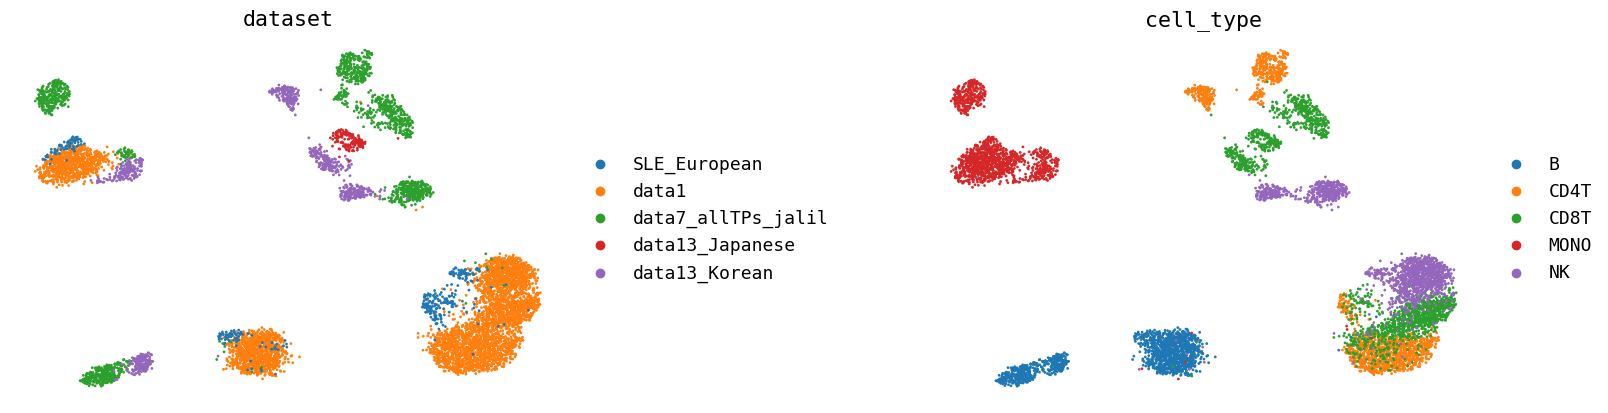

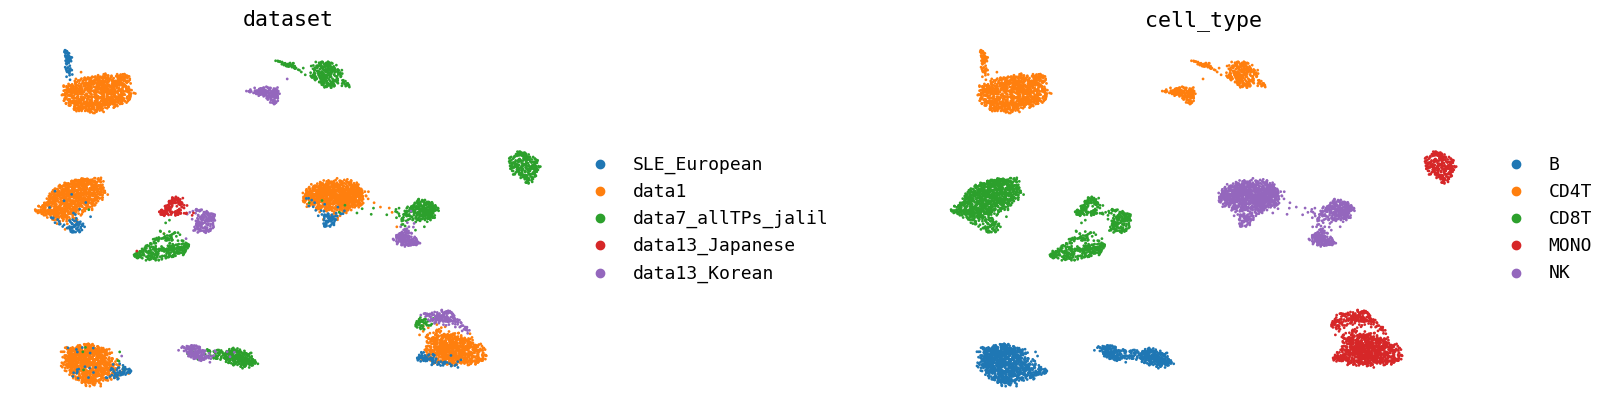

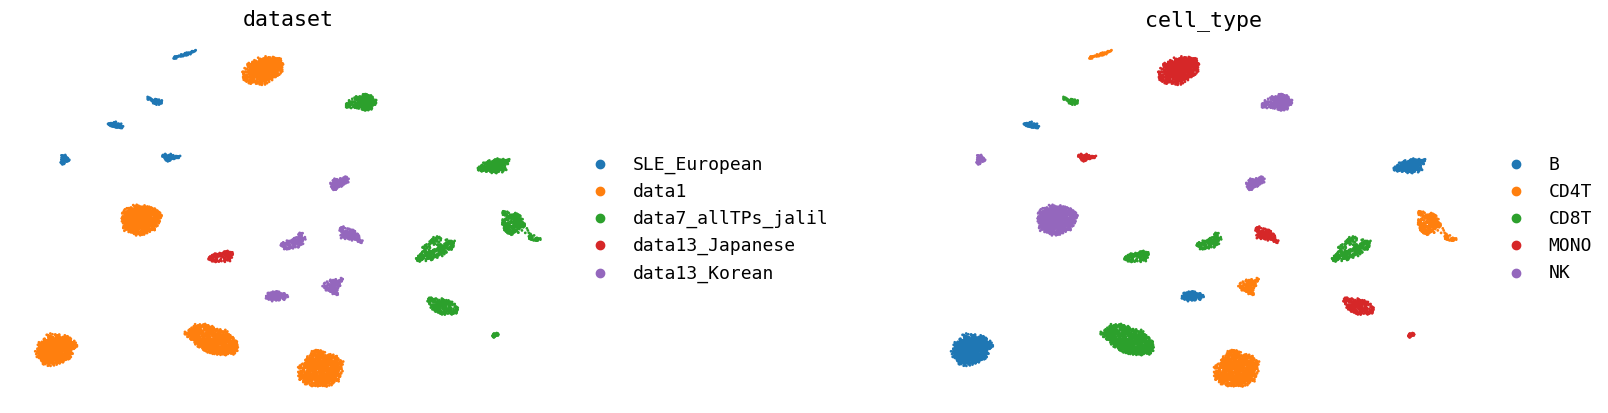

In [23]:
wrapper_umap(latent_dict['latent_basal'])
wrapper_umap(latent_dict['latent_corrected'])
wrapper_umap(latent_dict['latent_after'])

Spearman correlation (per donor): 0.43, R² (per donor): -0.90


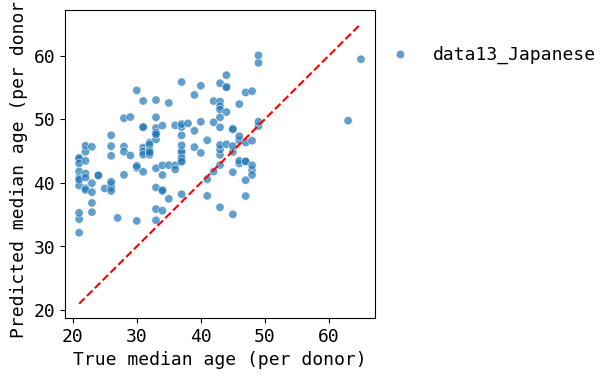

In [24]:
if data_type == 'sc':
    adata_corrected_bulk = bulkify_func(adata_corrected, covariates=['cell_type', 'donor_id', 'age'])
else:
    adata_corrected_bulk = adata_corrected

adata_corrected_bulk = adata_corrected_bulk[adata_corrected_bulk.obs['cell_type'] == 'CD8T'].copy()

adata_corrected_train = adata_corrected_bulk[adata_corrected_bulk.obs['dataset'].isin(train_datasets)].copy()
adata_corrected_test = adata_corrected_bulk[adata_corrected_bulk.obs['dataset'].isin(test_datasets)].copy()

obj = age_predictor()
obj.train(adata_corrected_train)
obj.predict(adata_corrected_test)